[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chreissel/sbi-tutorial-iaifi26/blob/main/02_gw_falcon.ipynb)

# Notebook 2 — A gravitational-wave chirp with `falcon`

**IAIFI Summer School · simulation-based inference · Session 2 (~60 min).**

Notebook 1 built NPE by hand on a 1-D toy. Here we point the same ideas — a
flow posterior, learned data compression, a sequential zoom — at a realistic
problem: inferring the **chirp mass** `Mc` and **luminosity distance** `dL` of
a gravitational-wave chirp buried in coloured detector noise. The observation
is a 4-second, 8192-sample strain time series.

We do it twice. First **by hand**, to see the physics (whitening, matched
filtering, score compression). Then in [`falcon`](https://github.com/cweniger/falcon),
a CLI-driven SBI framework where the model is a **graph written in YAML** and
the whole train/sample/zoom loop is three shell commands. The point of the
second half: the bookkeeping notebook 1 ended on is what a framework owns for
you.

> ### ▶️ Run this cell first
> **Runtime → Change runtime type → T4 GPU**, then run top to bottom. Notebook 2
> writes and reads files on disk (configs, a saved observation, samples), so we
> **clone** the repo rather than pip-installing it.
>
> **If you forked or renamed this repository**, change `chreissel/sbi-tutorial-iaifi26`
> below to your own `USER/REPO` — here, in the Colab badge above, and in the
> `wget` URL for the pre-computed run further down.

In [1]:
!git clone -q https://github.com/chreissel/sbi-tutorial-iaifi26.git
%cd sbi-tutorial-iaifi26
!pip install -q -r requirements.txt
# GWChirp lives in Weniger's course package; falcon's Ray workers import it too,
# so it must be pip-installed (not just pasted into a cell).
!pip install -q --no-deps git+https://github.com/cweniger/teaching-2606-ICTP-SAIFR.git

/content/sbi-tutorial-iaifi26
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.9/517.9 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 26.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from samma_sbi.simulators import GWChirp
from samma_sbi.viz import credible_levels   # 68% / 95% contour levels from a density grid

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

---
## 0 — The simulator

`GWChirp` forward-models the strain from an equal-mass binary black-hole
inspiral-merger-ringdown in coloured advanced-LIGO noise. Two parameters are
free — **chirp mass** `Mc` and **luminosity distance** `dL` — everything else
(mass ratio, coalescence time, sky location, ...) is baked in. The interface
mirrors the ball-throw from notebook 1.

In [3]:
sim = GWChirp()
print(f"observation length : {sim.n_samples} samples "
      f"({sim.duration}s x {sim.f_sample:.0f} Hz)")
print(f"prior : Mc in [{sim.mc_low}, {sim.mc_high}] Msun, "
      f"dL in [{sim.dl_low}, {sim.dl_high}] Mpc")

observation length : 8192 samples (4.0s x 2048 Hz)
prior : Mc in [20.0, 45.0] Msun, dL in [300.0, 1200.0] Mpc


---
## 1 — The data

**One observation.** Strain (signal + noise) over 4 seconds. The raw strain is
dominated by low-frequency noise and the signal is invisible; after
**whitening** (dividing each frequency by the noise amplitude `√S_n(f)`, so
every frequency contributes on an equal footing) the chirp leading into the
merger at `t = 2 s` pops out.

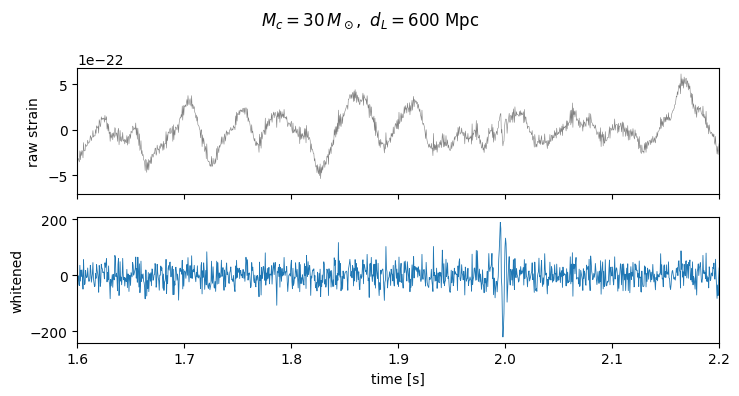

In [4]:
def whiten(x, sim):
    Xf = np.fft.rfft(x) / np.sqrt(sim.psd(sim.freqs))
    return np.fft.irfft(Xf, n=sim.n_samples)


theta_true = np.array([30.0, 600.0])   # Mc = 30 Msun, dL = 600 Mpc
x_demo = sim.simulate(theta_true, rng=np.random.default_rng(1))
t = np.arange(sim.n_samples) / sim.f_sample

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 4), sharex=True)
ax1.plot(t, x_demo, color="C7", lw=0.4); ax1.set_ylabel("raw strain")
ax2.plot(t, whiten(x_demo, sim), color="C0", lw=0.6)
ax2.set_xlabel("time [s]"); ax2.set_ylabel("whitened"); ax2.set_xlim(1.6, 2.2)
fig.suptitle(r"$M_c = 30\,M_\odot,\ d_L = 600$ Mpc")
fig.tight_layout(); plt.show()

**How the two parameters change the signal.** Below are noiseless whitened
templates: lighter `Mc` chirps for longer and reaches higher frequency; nearer
`dL` (smaller) is louder. Try changing the values.

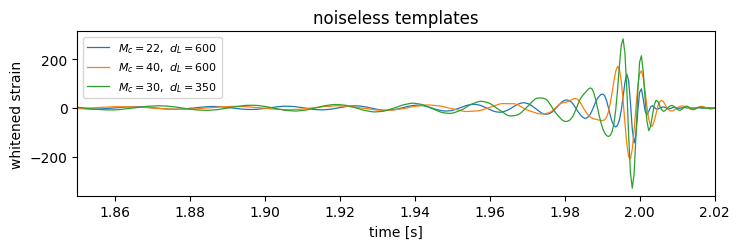

In [5]:
plt.figure(figsize=(7.5, 2.6))
for mc, dl, c in [(22, 600, "C0"), (40, 600, "C1"), (30, 350, "C2")]:
    h = np.fft.irfft(sim._waveform_fd(mc, dl), n=sim.n_samples)
    plt.plot(t, whiten(h, sim), color=c, lw=0.9, label=fr"$M_c={mc},\ d_L={dl}$")
plt.xlim(1.85, 2.02); plt.xlabel("time [s]"); plt.ylabel("whitened strain")
plt.legend(fontsize=8); plt.title("noiseless templates"); plt.tight_layout(); plt.show()

**Signal loudness (SNR) across the prior.** The same `Mc` at the near edge of
the prior is a loud, easy detection; at the far edge it is marginal. This range
is what makes the inference interesting.

In [6]:
for mc in [25, 32, 40]:
    snrs = [f"dL={dl}: {sim.optimal_snr(mc, dl):4.1f}" for dl in [300, 600, 1200]]
    print(f"Mc={mc:>3} Msun   " + "   ".join(snrs))

Mc= 25 Msun   dL=300: 28.9   dL=600: 14.4   dL=1200:  7.2
Mc= 32 Msun   dL=300: 35.0   dL=600: 17.5   dL=1200:  8.7
Mc= 40 Msun   dL=300: 39.4   dL=600: 19.7   dL=1200:  9.8


---
## 2 — From 8192 numbers to 2: a hand-built summary

We cannot feed 8192-sample strain into a small network. We need a **summary
statistic**: a few numbers that keep the information about `(Mc, dL)`. The
classical gravitational-wave tool is the **matched filter**: correlate the data
with a template, weighting each frequency by `1/S_n(f)` so noisy frequencies
count less,

$$ \langle d \mid g\rangle \;=\; \mathrm{Re}\sum_f \frac{d_f^{*}\, g_f}{S_n(f)}. $$

**Which templates?** A single matched filter against a fixed waveform is
sharply peaked: it only responds to signals very close to that template.
Instead we use the principled local choice: linearise the waveform around a
**fiducial** `θ₀` and project onto the two **score directions**, the
derivatives `∂h/∂Mc` and `∂h/∂dL`. For Gaussian noise these two numbers are the
locally-sufficient summary (the Fisher / Taylor picture). Intuitively they
measure *"how much heavier than fiducial"* and *"how loud"*. The simulator
provides the derivative templates; you build the filter.

### ✏️ EXERCISE 1 — implement the matched-filter summary

Implement `matched_filter`, then `my_summary`, using the two score templates
and the PSD from the simulator. The simulator also provides a
`whitening_matrix()` that rescales the two raw scores so that, under pure
noise, the summary is independent `N(0, 1)`. Check that your summary
reproduces `sim.summary(x)`.

In [7]:
g_mc, g_dl = sim.score_templates()      # derivative templates, freq-domain
psd = sim.psd(sim.freqs)                # noise PSD on the rfft grid
W = sim.whitening_matrix()              # 2x2, maps raw scores -> whitened summary


def matched_filter(x_td, template_fd, psd):
    Xf = np.fft.rfft(x_td)
    return float(np.real(np.sum(np.conj(Xf) * template_fd / psd)))


def my_summary(x_td):
    raw = np.array([matched_filter(x_td, g_mc, psd),
                    matched_filter(x_td, g_dl, psd)])
    return W @ raw

In [8]:
x_check = sim.simulate(np.array([30.0, 600.0]), rng=np.random.default_rng(3))
print("my_summary  :", my_summary(x_check).round(4))
print("sim.summary :", sim.summary(x_check).round(4))

my_summary  : [ -3.181  -15.5978]
sim.summary : [ -3.181  -15.5978]


**See the summary carry the parameters.** Below, each point is the summary of
one noisy observation. Sweeping `Mc` slides the cloud along one direction;
sweeping `dL` (loudness) slides it along the other. Under pure noise the cloud
sits at the origin with unit spread.

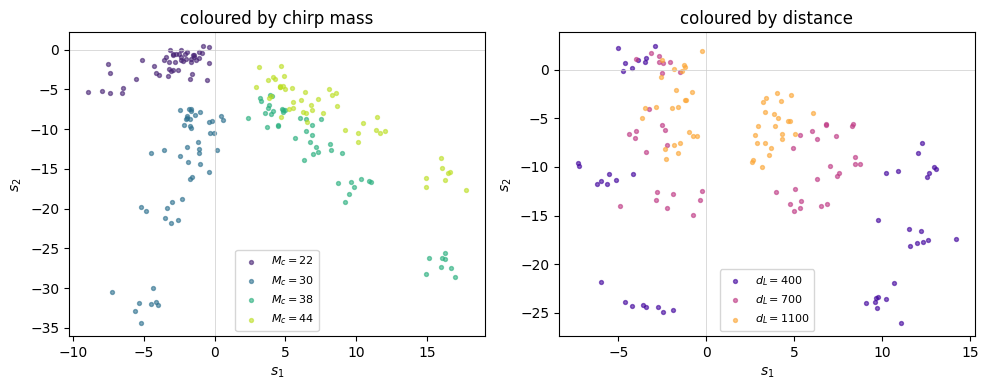

In [9]:
rng = np.random.default_rng(2)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# colour by Mc
for mc, c in zip([22, 30, 38, 44], plt.cm.viridis(np.linspace(0.1, 0.9, 4))):
    pts = np.array([sim.summary(sim.simulate(np.array([mc, dl]), rng=rng))
                    for dl in np.linspace(sim.dl_low, sim.dl_high, 6) for _ in range(8)])
    axes[0].scatter(pts[:, 0], pts[:, 1], s=8, color=c, alpha=0.6, label=fr"$M_c={mc}$")
# colour by dL
for dl, c in zip([400, 700, 1100], plt.cm.plasma(np.linspace(0.1, 0.8, 3))):
    pts = np.array([sim.summary(sim.simulate(np.array([mc, dl]), rng=rng))
                    for mc in np.linspace(sim.mc_low, sim.mc_high, 6) for _ in range(8)])
    axes[1].scatter(pts[:, 0], pts[:, 1], s=8, color=c, alpha=0.6, label=fr"$d_L={dl}$")
for ax, ttl in zip(axes, ["coloured by chirp mass", "coloured by distance"]):
    ax.axhline(0, color="0.8", lw=0.5); ax.axvline(0, color="0.8", lw=0.5)
    ax.set_xlabel(r"$s_1$"); ax.set_ylabel(r"$s_2$"); ax.legend(fontsize=8); ax.set_title(ttl)
fig.tight_layout(); plt.show()

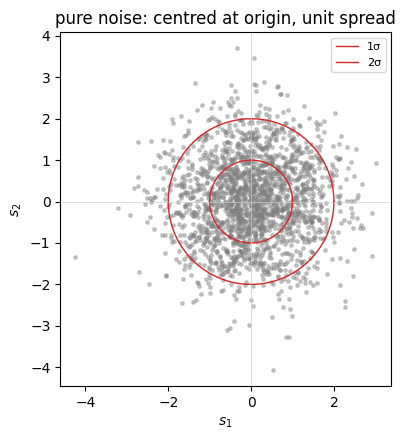

In [10]:
s = sim.summary(np.array([np.fft.irfft(sim._draw_noise_fd(rng), n=sim.n_samples)
                          for _ in range(2000)]))          # noise-only summaries
plt.figure(figsize=(4.5, 4.5))
plt.scatter(s[:, 0], s[:, 1], s=6, color="0.5", alpha=0.4)
th = np.linspace(0, 2 * np.pi, 200)
for r in (1, 2):
    plt.plot(r * np.cos(th), r * np.sin(th), "C3", lw=1, label=f"{r}σ")
plt.axhline(0, color="0.8", lw=0.5); plt.axvline(0, color="0.8", lw=0.5)
plt.gca().set_aspect("equal")
plt.xlabel(r"$s_1$"); plt.ylabel(r"$s_2$"); plt.legend(fontsize=8)
plt.title("pure noise: centred at origin, unit spread")
plt.tight_layout(); plt.show()

**The catch — this summary is only *locally* sufficient.** The score
directions `∂h/∂Mc`, `∂h/∂dL` are computed at a single fiducial `θ₀`, so the
summary is a *linearisation* of the waveform about that point. Near `θ₀` it
keeps essentially all the information; far from `θ₀` the true waveform curves
away from its tangent plane, and the two numbers start to lose information —
the mean-map bends, and at low SNR the noise smears whatever is left. So this
hand-built compression degrades exactly where the problem is hardest: faint
signals far from fiducial. That is the hook: we want a compression that
*learns* to stay sufficient across the whole prior, and adapts as we zoom in.
`falcon` gives us both, by swapping one block of a config.

---
## 3 — The same problem in `falcon`

In `falcon` you declare a **graph of random variables** in YAML. Each node has
a `simulator` (forward model) and optionally an `estimator` (the learned
posterior). Falcon iterates simulate ↔ train, managing the sample buffer. **The
YAML *is* the graphical model.**

Our graph has two nodes:

- **`z`** — the parameters `(Mc, dL)`, with a `falcon.priors.Product` prior and
  a `falcon.estimators.Flow` (a neural spline flow) as its estimator. It is
  inferred *from* the data (`evidence: [x]`).
- **`x`** — the observation, produced by running `GWChirp` on `z`
  (`parents: [z]`), with `observed:` pointing at a strain we save to disk.

The estimator's `embedding` block is where compression lives. For this first
run it is exactly the hand-built §2 summary (a *fixed*, non-learned module that
turns 8192 strain samples into 2 whitened scores) followed by a trivial
`Linear` layer — i.e. we hand falcon the same 2 numbers we built by hand, and
let it learn only the flow on top.

First, the thin Python glue falcon imports: a simulator wrapper around
`GWChirp`, the fixed score-compression module, and (for §4) a small CNN. We
`%%writefile` it so it lands on disk where falcon's workers can import it.

In [11]:
%%writefile model.py
"""Thin falcon wrappers around Weniger's GWChirp simulator.

Falcon imports this module in its Ray workers (see paths.imports in the config).
A simulator node is any class with a `simulate_batch(self, batch_size, *parents)`
method returning a numpy array; an embedding is any nn.Module mapping the
observation tensor to a feature vector.
"""
import numpy as np
import torch
import torch.nn as nn
from samma_sbi.simulators import GWChirp

_SIM = GWChirp()
_F = len(_SIM.freqs)                       # number of rfft bins


class GWStrain:
    """Data node: parameters z = (Mc, dL) -> raw 8192-sample strain."""

    def simulate_batch(self, batch_size, z):
        z = np.asarray(z, dtype=float).reshape(-1, 2)      # (B, 2)
        return _SIM.simulate(z).astype(np.float32)          # (B, n_samples)


class Summary(nn.Module):
    """Fixed hand-built score compression: (B, 8192) strain -> (B, 2) scores.

    This is exactly the matched-filter summary from section 2, wrapped as a
    (non-trainable) embedding so falcon can use it as a data compressor.
    """

    def __init__(self):
        super().__init__()
        g_mc, g_dl = _SIM.score_templates()                # complex, (F,)
        psd = _SIM.psd(_SIM.freqs)                          # (F,)
        W = _SIM.whitening_matrix()                         # (2, 2)
        # The score inner product divides by S_n(f) ~ 1e-49, i.e. multiplies by
        # ~1e49 — far past float32's ~3e38 ceiling — so we keep this fixed
        # compression in float64 (Weniger's numpy summary is float64 too) and
        # only cast the O(1) result back down. Store the complex templates as
        # real/imag buffers.
        self.register_buffer("g_re", torch.tensor(np.stack([g_mc.real, g_dl.real]), dtype=torch.float64))
        self.register_buffer("g_im", torch.tensor(np.stack([g_mc.imag, g_dl.imag]), dtype=torch.float64))
        self.register_buffer("psd", torch.tensor(psd, dtype=torch.float64))
        self.register_buffer("W", torch.tensor(W, dtype=torch.float64))

    def forward(self, x):
        x = x.double()
        Xf = torch.fft.rfft(x, dim=-1)                     # (B, F) complex128
        Xr, Xi = Xf.real, Xf.imag                          # (B, F)
        # raw_i = Re sum_f conj(X) * g_i / psd = sum (Xr*g_re + Xi*g_im)/psd
        num_re = Xr[:, None, :] * self.g_re[None] + Xi[:, None, :] * self.g_im[None]
        raw = (num_re / self.psd[None, None]).sum(-1)      # (B, 2)
        return (raw @ self.W.T).float()                    # (B, 2), back to float32


class CNN1D(nn.Module):
    """Small 1-D CNN over the RAW 8192-sample strain -> feature vector.

    The strain is ~1e-22, so it MUST be normalized before the convolutions or
    their gradients vanish and the flow learns nothing. Standardize each input
    to zero-mean / unit-variance first."""

    def __init__(self, out_features=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 8, 33, stride=4, padding=16), nn.ReLU(),
            nn.Conv1d(8, 16, 17, stride=4, padding=8), nn.ReLU(),
            nn.Conv1d(16, 32, 9, stride=4, padding=4), nn.ReLU(),
            nn.AdaptiveAvgPool1d(4), nn.Flatten(),
            nn.Linear(32 * 4, out_features),
        )

    def forward(self, x):
        x = x.float()
        # normalize the inputs to avoid problem with small (10^-22) numbers
        x = (x - x.mean(dim=-1, keepdim=True)) / (x.std(dim=-1, keepdim=True) + 1e-30)
        return self.net(x.unsqueeze(1))         # (B, 1, 8192) -> (B, out)

Writing model.py


Save one observation to disk (raw strain at a known `(Mc, dL)`), so the
config's `observed:` has a file to point at. We keep the truth around to score
the posterior later.

In [12]:
theta_obs = np.array([32.0, 700.0])       # Mc = 32 Msun, dL = 700 Mpc
x_obs = sim.simulate(theta_obs, rng=np.random.default_rng(42)).astype(np.float32)
np.save("x_obs.npy", x_obs)
print("saved x_obs.npy", x_obs.shape, " SNR ~", round(sim.optimal_snr(*theta_obs), 1))

saved x_obs.npy (8192,)  SNR ~ 15.0


### ✏️ EXERCISE 2 — write the falcon config

Fill in the two `# TODO` values in the config below so it matches the graph we
described: a `Product` prior over `(Mc, dL)` on the simulator's own prior range,
and a data node whose `observed:` points at the file we just saved. Everything
else — the flow estimator, the `Summary → Linear` embedding, the buffer — is
already wired against falcon's real schema. Writing it with `%%writefile` means
you watch the whole graphical model being built as one YAML file.

In [13]:
%%writefile config_summary.yml
logging:
  wandb:
    enabled: false                 # keep everything local; no external logging
  local:
    enabled: true

paths:
  imports: ["."]                   # import model.py from the working directory

buffer:
  min_samples: 512                # start training once this many sims exist
  max_samples: 2048
  validation_samples: 256
  simulate_count: 512
  simulate_when_full: false

graph:
  z:
    evidence: [x]                  # z is inferred from x
    simulator:
      _target_: falcon.priors.Product
      priors:
        - ['uniform', 20.0, 45.0]
        - ['uniform', 300.0, 1200.0]
    estimator:
      _target_: falcon.estimators.Flow
      max_epochs: 30
      net_type: nsf                # neural spline flow
      lr: 0.003
      gamma: 0.5
      embedding:                   # <-- the ONE block we swap in section 4
        _target_: torch.nn.Linear
        in_features: 2
        out_features: 2
        _input_:
          _target_: model.Summary  # fixed hand-built score compression
          _input_: [x]
      batch_size: 128
      early_stop_patience: 20
      theta_norm: true
      lr_decay_factor: 0.5
      lr_patience: 8
      discard_samples: false
      use_best_models: true
    ray:
      num_gpus: 0

  x:
    parents: [z]
    simulator:
      _target_: model.GWStrain
    observed: "./x_obs.npy"

sample:
  posterior:
    n: 800

Writing config_summary.yml


**The YAML is the graphical model.** Ask falcon to draw it — every node, its
forward dependencies, and which node is observed:

In [14]:
!falcon graph -c config_summary.yml


* z  ← x
|
* x (observed)

Nodes: 2 | Observed: x | Estimators: z


Now train (simulate ↔ fit the flow) and draw posterior samples. Both are one
shell command each. This is a small, fast run — the 2-number summary is nearly
sufficient near this loud-ish signal, so the flow converges quickly.

In [15]:
!falcon launch -c config_summary.yml -o output/run_summary --no-interactive
!falcon sample posterior -c config_summary.yml -o output/run_summary

falcon ▁▂▅▇█▆▃▂▁▁ v0.5.1
2026-07-30T01:26:33 [INFO] falcon v0.5.1
2026-07-30T01:26:33 [INFO] Output: output/run_summary
2026-07-30T01:26:33 [INFO] Ray: 172.28.0.12:44299 (new local instance)
2026-07-30T01:26:33 [INFO] Resources: 2 CPU, 1 GPU, 8.6 GB
2026-07-30T01:26:33 [INFO] Falcon graph structure:
  Node name          List of parents                                 Class name
* z               <-                                               | falcon.priors.Product
* x               <- z                                             | model.GWStrain      

2026-07-30T01:26:33 [INFO] Observed: x [1, 8192]
2026-07-30T01:26:33 [INFO] Spinning up graph...
2026-07-30T01:26:39 [INFO]   ✓ z
2026-07-30T01:26:39 [INFO]   ✓ x
2026-07-30T01:26:44 [INFO] Generating 768 initial samples...
2026-07-30T01:26:47 [INFO] Initial samples ready (0 loaded, 768 generated)
2026-07-30T01:26:47 [INFO] 
2026-07-30T01:26:47 [INFO] Starting analysis.
2026-07-30T01:26:47 [INFO] [z] Training started
2026-07-30T01:27

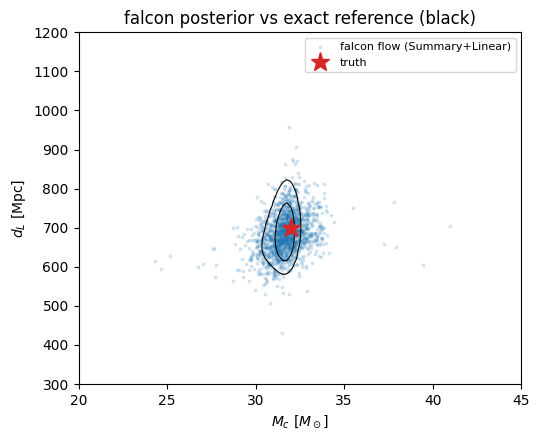

In [16]:
def load_falcon_posterior(run_dir):
    """Load all posterior samples falcon wrote under run_dir/samples/posterior.

    Falcon saves one NPZ file per sample, each holding a (2,) array under key
    'z', so we stack them into (N, 2)."""
    import glob
    files = sorted(glob.glob(f"{run_dir}/samples/posterior/*.npz"))
    zs = [np.atleast_2d(np.load(f)["z"]) for f in files]   # each -> (1, 2) or (n, 2)
    return np.concatenate(zs, axis=0)                       # (N, 2)


post_summary = load_falcon_posterior("output/run_summary")

# The exact reference posterior in summary space (best possible given 2 scores).
s_obs = sim.summary(x_obs)
mc_g, dl_g, p_ref = sim.true_posterior_summary(s_obs, n_mc=120, n_dl=120)

plt.figure(figsize=(5.5, 4.5))
plt.contour(*np.meshgrid(mc_g, dl_g, indexing="ij"), p_ref,
            levels=credible_levels(p_ref), colors="k", linewidths=0.8)
plt.scatter(post_summary[:, 0], post_summary[:, 1], s=3, alpha=0.15, color="C0",
            label="falcon flow (Summary+Linear)")
plt.plot(*theta_obs, "C3*", ms=14, label="truth")
plt.xlabel(r"$M_c\ [M_\odot]$"); plt.ylabel(r"$d_L$ [Mpc]")
plt.xlim(sim.mc_low, sim.mc_high); plt.ylim(sim.dl_low, sim.dl_high)
plt.legend(fontsize=8); plt.title("falcon posterior vs exact reference (black)")
plt.tight_layout(); plt.show()

The flow sits on the reference contours: with the hand-built 2-number summary,
falcon recovers the same posterior we could have gotten from notebook 1's
machinery — but declared in YAML, with the simulate/train/sample loop handled
for us.

---
## 4 — A learned embedding, and adaptivity

Now change **one block**. The §2 summary was fixed and only locally
sufficient. Swap it for a small **1-D CNN over the raw 8192 samples** — same
graph, same flow, same everything else — and let the network *learn* the
compression. In the config below only the `embedding:` block differs from
`config_summary.yml`.

In [17]:
%%writefile config_cnn.yml
logging:
  wandb:
    enabled: false
  local:
    enabled: true

paths:
  imports: ["."]

buffer:
  min_samples: 4096
  max_samples: 8192
  validation_samples: 512
  simulate_count: 2048
  simulate_interval: 1
  simulate_when_full: false

graph:
  z:
    evidence: [x]
    simulator:
      _target_: falcon.priors.Product
      priors:
        - ['uniform', 20.0, 45.0]
        - ['uniform', 300.0, 1200.0]
    estimator:
      _target_: falcon.estimators.Flow
      max_epochs: 80               # short training, on purpose
      net_type: nsf
      lr: 0.003
      gamma: 0.5
      embedding:                   # <-- the ONLY change: a learned CNN on raw x
        _target_: model.CNN1D
        out_features: 8
        _input_: [x]
      batch_size: 256
      early_stop_patience: 12
      cache_on_device: true
      theta_norm: true
      lr_decay_factor: 0.5
      lr_patience: 8
      discard_samples: false
      use_best_models: true
    ray:
      num_gpus: 1

  x:
    parents: [z]
    simulator:
      _target_: model.GWStrain
    observed: "./x_obs.npy"

sample:
  posterior:
    n: 800

Writing config_cnn.yml


In [18]:
!falcon launch -c config_cnn.yml -o output/run_cnn --no-interactive
!falcon sample posterior -c config_cnn.yml -o output/run_cnn

falcon ▁▂▅▇█▆▃▂▁▁ v0.5.1
2026-07-30T01:33:19 [INFO] falcon v0.5.1
2026-07-30T01:33:19 [INFO] Output: output/run_cnn
2026-07-30T01:33:19 [INFO] Ray: 172.28.0.12:33917 (new local instance)
2026-07-30T01:33:19 [INFO] Resources: 2 CPU, 1 GPU, 8.6 GB
2026-07-30T01:33:19 [INFO] Falcon graph structure:
  Node name          List of parents                                 Class name
* z               <-                                               | falcon.priors.Product
* x               <- z                                             | model.GWStrain      

2026-07-30T01:33:19 [INFO] Observed: x [1, 8192]
2026-07-30T01:33:19 [INFO] Spinning up graph...
2026-07-30T01:33:24 [INFO]   ✓ z
2026-07-30T01:33:24 [INFO]   ✓ x
2026-07-30T01:33:30 [INFO] Generating 4608 initial samples...
2026-07-30T01:33:48 [INFO] Initial samples ready (0 loaded, 4608 generated)
2026-07-30T01:33:48 [INFO] 
2026-07-30T01:33:48 [INFO] Starting analysis.
2026-07-30T01:33:48 [INFO] [z] Training started
2026-07-30T01:35:0

In [23]:
post_cnn_live = load_falcon_posterior("output/run_cnn")

The CNN has to *learn* the compression the §2 summary got for free from
physics. Compare the two falcon posteriors against the same reference:

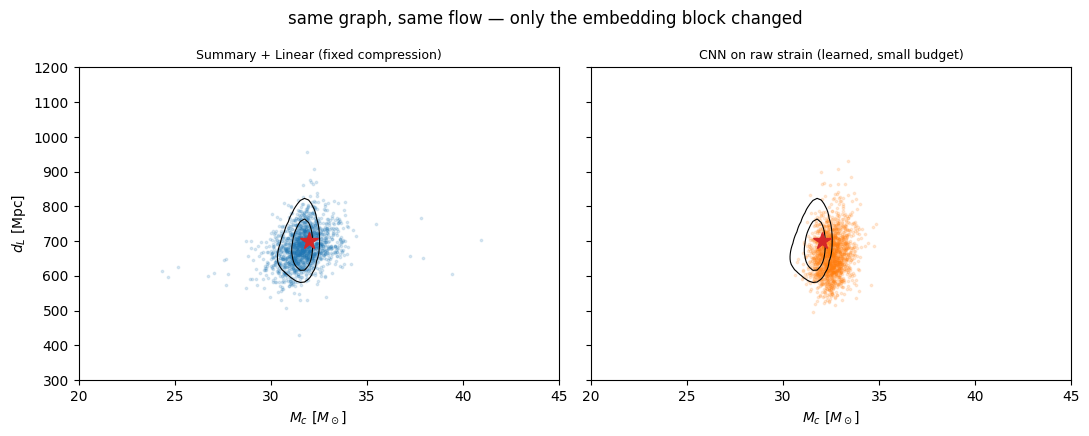

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)
for ax, post, ttl, c in [
        (axes[0], post_summary, "Summary + Linear (fixed compression)", "C0"),
        (axes[1], post_cnn_live, "CNN on raw strain (learned, small budget)", "C1")]:
    ax.contour(*np.meshgrid(mc_g, dl_g, indexing="ij"), p_ref,
               levels=credible_levels(p_ref), colors="k", linewidths=0.8)
    ax.scatter(post[:, 0], post[:, 1], s=3, alpha=0.15, color=c)
    ax.plot(*theta_obs, "C3*", ms=13)
    ax.set_xlabel(r"$M_c\ [M_\odot]$"); ax.set_title(ttl, fontsize=9)
    ax.set_xlim(sim.mc_low, sim.mc_high); ax.set_ylim(sim.dl_low, sim.dl_high)
axes[0].set_ylabel(r"$d_L$ [Mpc]")
fig.suptitle("same graph, same flow — only the embedding block changed")
fig.tight_layout(); plt.show()

---
## 5 — Composability, and where this goes at scale

The reason to declare the model as a graph is that you can **grow** it without
rewriting anything. A real detection is never a clean two-parameter chirp:
there is almost always a **nuisance** — a second, fainter overlapping signal, a
drifting noise level, a glitch. In falcon that is a few extra lines of YAML: add
a node for the nuisance's parameters, give it a prior, and feed it into the data
node. Because the nuisance node carries **no `evidence`**, falcon samples it and
**marginalises** over it automatically — it is never inferred, only integrated
out, exactly how you should treat a parameter you don't care about.

Below, `z_nuis` is a second overlapping chirp (its own `(Mc, dL)`); the data
node now runs `GWStrainOverlap`, which adds a fainter second signal on top of
the one we care about. The estimator on `z` is unchanged. First the extra glue:

In [25]:
%%writefile model_nuisance.py
"""Adds a nuisance: a second, fainter overlapping chirp, marginalised over."""
import numpy as np
from samma_sbi.simulators import GWChirp

_SIM = GWChirp()


class GWStrainOverlap:
    """Data node: main signal z, plus a faint overlapping signal z_nuis."""

    def simulate_batch(self, batch_size, z, z_nuis):
        z = np.asarray(z, dtype=float).reshape(-1, 2)
        z_nuis = np.asarray(z_nuis, dtype=float).reshape(-1, 2)
        x = _SIM.simulate(z)                             # main signal + noise
        # add a faint, noiseless second chirp (0.3x amplitude) as confusion
        for i in range(len(z_nuis)):
            h2 = np.fft.irfft(_SIM._waveform_fd(float(z_nuis[i, 0]),
                                                float(z_nuis[i, 1])),
                              n=_SIM.n_samples)
            x[i] = x[i] + 0.3 * h2
        return x.astype(np.float32)

Writing model_nuisance.py


In [27]:
%%writefile config_nuisance.yml
logging:
  wandb: {enabled: false}
  local: {enabled: true}

paths:
  imports: ["."]

buffer:
  min_samples: 1024
  max_samples: 4096
  validation_samples: 256
  simulate_count: 256
  simulate_interval: 1
  simulate_when_full: false

graph:
  z:                               # the signal we care about — inferred
    evidence: [x]
    simulator:
      _target_: falcon.priors.Product
      priors:
        - ['uniform', 20.0, 45.0]
        - ['uniform', 300.0, 1200.0]
    estimator:
      _target_: falcon.estimators.Flow
      max_epochs: 60
      net_type: nsf
      lr: 0.003
      gamma: 0.5
      embedding:
        _target_: torch.nn.Linear
        in_features: 2
        out_features: 2
        _input_:
          _target_: model.Summary
          _input_: [x]
      batch_size: 128
      early_stop_patience: 20
      theta_norm: true
      use_best_models: true
    ray:
      num_gpus: 0

  z_nuis:                          # the nuisance — a prior, NO evidence => marginalised
    simulator:
      _target_: falcon.priors.Product
      priors:
        - ['uniform', 20.0, 45.0]
        - ['uniform', 300.0, 1200.0]

  x:
    parents: [z, z_nuis]           # data now depends on both
    simulator:
      _target_: model_nuisance.GWStrainOverlap
    observed: "./x_obs.npy"

sample:
  posterior:
    n: 800

Overwriting config_nuisance.yml


The graph changed; nothing else did. Ask falcon to draw it — note `z_nuis`
feeding `x` with no arrow coming back out of it (it is marginalised, not
inferred):

In [29]:
!falcon graph -c config_nuisance.yml


* z_nuis
|
| * z  ← x
| |
|/
* x (observed)

Nodes: 3 | Observed: x | Estimators: z


### Where this goes at production scale

What we ran is a two-parameter toy on a Colab GPU. The same three commands,
the same YAML shape, scale to the real thing:

- **9+ parameters** — full massive-black-hole-binary source models (masses,
  spins, sky location, orientation, phase, ...), most of them nuisances
  marginalised exactly as above;
- **real waveform stacks** — `GWStrain` swapped for a production waveform
  (e.g. `lisabeta`), simulated live inside the loop;
- **the adaptive/sequential zoom** turned up to many rounds, so the training
  buffer converges to (a tempered version of) the posterior — the mechanism
  notebook 1 §6 introduced by hand.

This is exactly the setup behind the **LDC1 MBHB** results of the dynamic-SBI
work (Alvey, Lyu, Weniger et al., **arXiv:2510.13997**): the same
`falcon` graph, one flow per parameter block, run for a handful of rounds with
waveforms simulated live. The whole point of the framework is that going from
this notebook to that paper is a change of *config and simulator*, not a
rewrite of the inference.

### Where this leaves you

- A falcon model is a **graph in YAML**: prior nodes with `Flow` estimators,
  simulator nodes, an `observed:` file — the graph is the graphical model.
- Compression is **one swappable block**: a fixed physics summary or a learned
  CNN, compared honestly on **simulation budget**.
- Nuisances are **a few lines of YAML** and are marginalised for free.
- The path to production is more nodes and a bigger simulator — not new code.